Repare que o código depois de # não aparece. Isso é chamado de comentário. O interpretador do python ignora os comentários



# Aula 3


# *Análise* com agrupamentos, histograma e boxplot múltiplos, tabela de contingência e regressão linear

In [ ]:
#@title **Importar biblioteca pandas** { vertical-output: true, form-width: "60%" }
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter


In [ ]:
#@title **Montar Google Drive e dar permissão** { vertical-output: true, form-width: "30%" }
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#@title **Upload da base de dados**
# caminho onde está o arquivo - troque pela sua pasta
sinasc = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/SINASC_2020_comp.csv")

sinasc.head()


,n,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,...,TPDOCRESP,DTDECLARAC,ESCMAEAGR1,STDNEPIDEM,STDNNOVA,CODPAISRES,TPROBSON,PARIDADE,KOTELCHUCK,CONTADOR
0,1,1,2552086.0,230640,1,34,1.0,4.0,NaN,3.0,...,0.0,21022020.0,6.0,0,1,1,3,1,5,267059
1,2,1,2218690.0,313170,1,20,1.0,4.0,999992.0,0.0,...,0.0,NaN,6.0,0,1,1,3,1,5,606117
2,3,1,3394514.0,230440,1,21,1.0,4.0,422310.0,0.0,...,3.0,4092020.0,12.0,0,1,1,11,0,5,1661732
3,4,1,2702983.0,260600,1,25,5.0,4.0,521110.0,0.0,...,4.0,30062020.0,6.0,0,1,1,3,1,5,355894
4,5,1,2748223.0,350750,1,31,2.0,5.0,521110.0,1.0,...,3.0,19062020.0,7.0,0,1,1,3,1,5,830956


Após importado, é possível observar que há 64 atributos na base de dados. A [documentação disponibilizada](ftp://ftp.datasus.gov.br/dissemin/publicos/SINASC/NOV/DOCS/Estrutura_SINASC_para_CD.pdf) descreve os seguintes atributos:

In [ ]:
print(sinasc.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 62 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   n           5000 non-null   int64  
 1   ORIGEM      5000 non-null   int64  
 2   CODESTAB    4941 non-null   float64
 3   CODMUNNASC  5000 non-null   int64  
 4   LOCNASC     5000 non-null   int64  
 5   IDADEMAE    5000 non-null   int64  
 6   ESTCIVMAE   4976 non-null   float64
 7   ESCMAE      4975 non-null   float64
 8   CODOCUPMAE  4603 non-null   float64
 9   QTDFILVIVO  4912 non-null   float64
 10  QTDFILMORT  4852 non-null   float64
 11  CODMUNRES   5000 non-null   int64  
 12  GESTACAO    4932 non-null   float64
 13  GRAVIDEZ    4996 non-null   float64
 14  PARTO       4999 non-null   float64
 15  CONSULTAS   5000 non-null   int64  
 16  DTNASC      5000 non-null   int64  
 17  HORANASC    4996 non-null   float64
 18  SEXO        5000 non-null   int64  
 19  APGAR1      4924 non-null  

In [ ]:
sinasc['ESTCIVMAE'] = sinasc['ESTCIVMAE'].astype('category')
sinasc['LOCNASC'] = sinasc['LOCNASC'].astype('category')
sinasc['PARTO'] = sinasc['PARTO'].astype('category')
sinasc['ESCMAE'] = sinasc['ESCMAE'].astype('category')

print('ESTCIVMAE:', sinasc['ESTCIVMAE'].dtypes)
print('ESCMAE:', sinasc['ESCMAE'].dtypes)


ESTCIVMAE: category
ESCMAE: category


In [ ]:
#@title **Extração dos diferentes grupos** { form-width: "20px" }
# parto normal
normal = sinasc[(sinasc['PARTO'] == 1)]
# parto cesárea
cesarea = sinasc[(sinasc['PARTO'] == 2)]

#nenhuma consulta prá-natal
pre_natal_0 = sinasc[(sinasc['CONSULTAS'] == 1)]
#1-3 consultas prá-natal
pre_natal_1_3 = sinasc[(sinasc['CONSULTAS'] == 2)]
#4-6 consultas prá-natal
pre_natal_4_6 = sinasc[(sinasc['CONSULTAS'] == 3)]
#7+ consultas prá-natal
pre_natal_7 = sinasc[(sinasc['CONSULTAS'] == 4)]

#gravidez única
gravidez_1= sinasc[(sinasc['GRAVIDEZ'] == 1)]
#gravidez dupla
gravidez_2= sinasc[(sinasc['GRAVIDEZ'] == 2)]
#gravidez tripla ou mais
gravidez_3= sinasc[(sinasc['GRAVIDEZ'] == 3)]

#escolaridade nenhuma
escolaridade_0= sinasc[(sinasc['ESCMAE'] == 1)]
#escolaridade 1-3 anos
escolaridade_1_3= sinasc[(sinasc['ESCMAE'] == 2)]
#escolaridade 4-7 anos
escolaridade_4_7= sinasc[(sinasc['ESCMAE'] == 3)]
#escolaridade 8-11 anos
escolaridade_8_11= sinasc[(sinasc['ESCMAE'] == 4)]
#escolaridade 12+ anos
escolaridade_12= sinasc[(sinasc['ESCMAE'] == 5)]

#sexo_anomal
sexo_anomal = sinasc[(sinasc['SEXO']!= '') & (sinasc['SEXO']!= '9') &  (sinasc['IDANOMAL']!= '') & (sinasc['IDANOMAL']!= '9')]

#gravidez_parto
gravidez_parto = sinasc[(sinasc['GRAVIDEZ']!= '') & (sinasc['GRAVIDEZ']!= '9') &  (sinasc['PARTO']!= '') & (sinasc['PARTO']!= '9')]

gravidez_gestacao = sinasc[(sinasc['GRAVIDEZ']!= '') & (sinasc['GRAVIDEZ']!= '9') &  (sinasc['GESTACAO']!= '') & (sinasc['GESTACAO']!= '9')]


filhosvivos = sinasc[(sinasc['ESTCIVMAE']==1) & (sinasc['QTDFILVIVO']!='' ) & (sinasc['QTDFILVIVO'].notnull())][['QTDFILVIVO']]
idade = sinasc[(sinasc['ESTCIVMAE']==1) & (sinasc['IDADEMAE'].notnull())][['IDADEMAE']]

# idade + filhos vivos
idade_filhosvivos = pd.concat([filhosvivos,idade], axis=1).dropna()
idade_filhosvivos

,QTDFILVIVO,IDADEMAE
0,3.0,34
1,0.0,20
2,0.0,21
5,0.0,24
8,0.0,18
...,...,...
4992,3.0,34
4993,0.0,20
4996,0.0,20
4997,2.0,25


In [ ]:
#@title **Cesárea *x* parto normal - idade das mães** { vertical-output: true }

# média
media_1 = normal['IDADEMAE'].mean()
media_2 = cesarea['IDADEMAE'].mean()

# variância
var_1 = normal['IDADEMAE'].var()
var_2 = cesarea['IDADEMAE'].var()

# desvio padrão
dp_1 = normal['IDADEMAE'].std()
dp_2 = cesarea['IDADEMAE'].std()

# ampliture interquartil
q_1 = normal['IDADEMAE'].quantile([0.25, 0.75]).values
q_2 = cesarea['IDADEMAE'].quantile([0.25, 0.75]).values
iqr_1 = q_1[1] - q_1[0]
iqr_2 = q_2[1] - q_2[0]

# coeficiente de variação
cv_1 = dp_1*100/media_1
cv_2 = dp_2*100/media_2

# organizando em um dataframe
resultado = pd.DataFrame({
    'Parto':['Normal', 'Cesárea'],
    'média':[media_1,media_2],
    'var':[var_1, var_2],
    'dp':[dp_1, dp_2],
    'iqr':[iqr_1, iqr_2],
    'cv':[cv_1, cv_2]} ).set_index('Parto')
resultado
resultado

,média,var,dp,iqr,cv
Parto,,,,,
Normal,25.760436,43.450413,6.591693,9.0,25.588436
Cesárea,28.557593,41.273066,6.424412,9.0,22.496335


## Histograma

<div align='justify'>

O histograma mede a distribuição das frequências de um intervalo ou faixas. A tabela de frequências serve como base para construir o histograma.

Histograma do pandas suporta criar o gráfico a partir do DataFrame apenas para colunas quantitativas. Para colunas qualitativas, deve-se utilizar a tabela de frequências e utilizar o método plot.

</div>

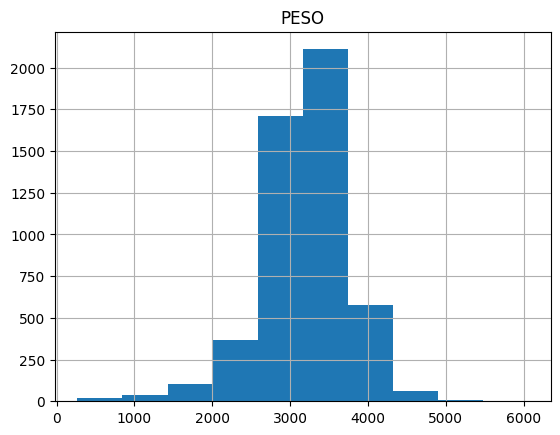

In [ ]:
#@title **Histograma de Faixa Etária** { vertical-output: true, form-width: "60%" }
hist1 = sinasc.hist(['PESO'])


<ipython-input-18-354f7c7ff049>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = sinasc.hist(['PESO'], by='PARTO', bins=25, grid=False, figsize=(8,10), layout=(3,1), sharex=True, color='#86bf91', zorder=2, rwidth=0.9)


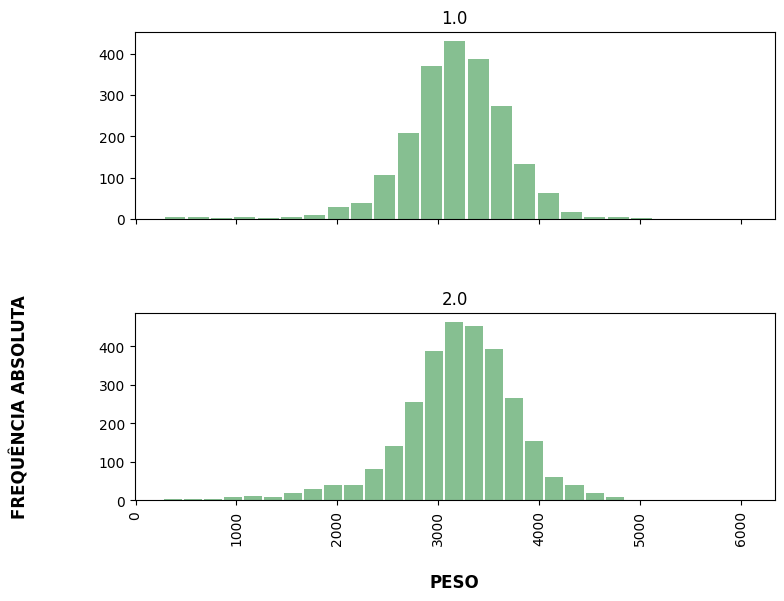

In [ ]:
ax = sinasc.hist(['PESO'], by='PARTO', bins=25, grid=False, figsize=(8,10), layout=(3,1), sharex=True, color='#86bf91', zorder=2, rwidth=0.9)

for i,x in enumerate(ax):

    # Título do eixo x
    x.set_xlabel("PESO", labelpad=20, weight='bold', size=12)

    # Título do eixo y
    if i == 1:
        x.set_ylabel("FREQUÊNCIA ABSOLUTA", labelpad=50, weight='bold', size=12)


## Box-plot

<div align='justify'>

O box plot é um gráfico interessante para mostrar diversas medidas-resumo em uma só figura, resumindo a variabilidade e simetria dos dados. Ele é construído a partir dos quartis (Q1, Q2, Q3) e dos limites superior e inferior:


*   Limite superior: Q3 + 1.5 x (Q3 -Q1)
*   Limite inferior: Q1 - 1.5 x (Q3 -Q1)

As observações acima do limite superior e abaixo do limite inferior são *outliers* ou valores atípicos.

</div>


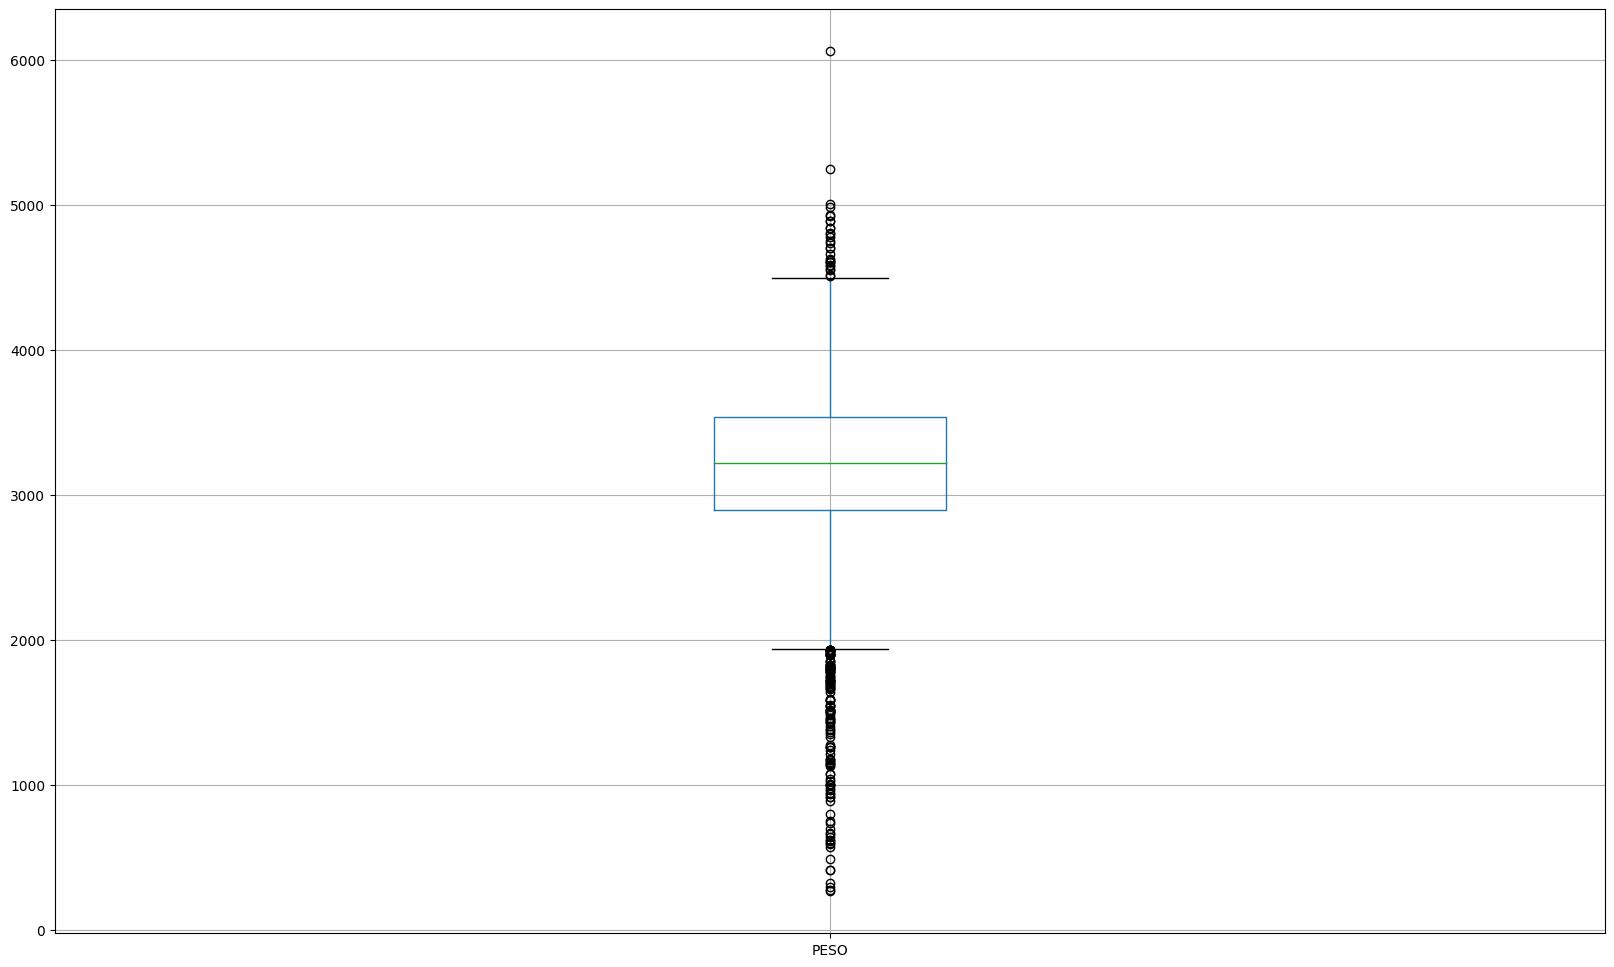

In [ ]:
#@title **Box-plot para o peso** { vertical-output: true, form-width: "60%" }
bp = sinasc.boxplot(column=['PESO'], figsize=(20,12))


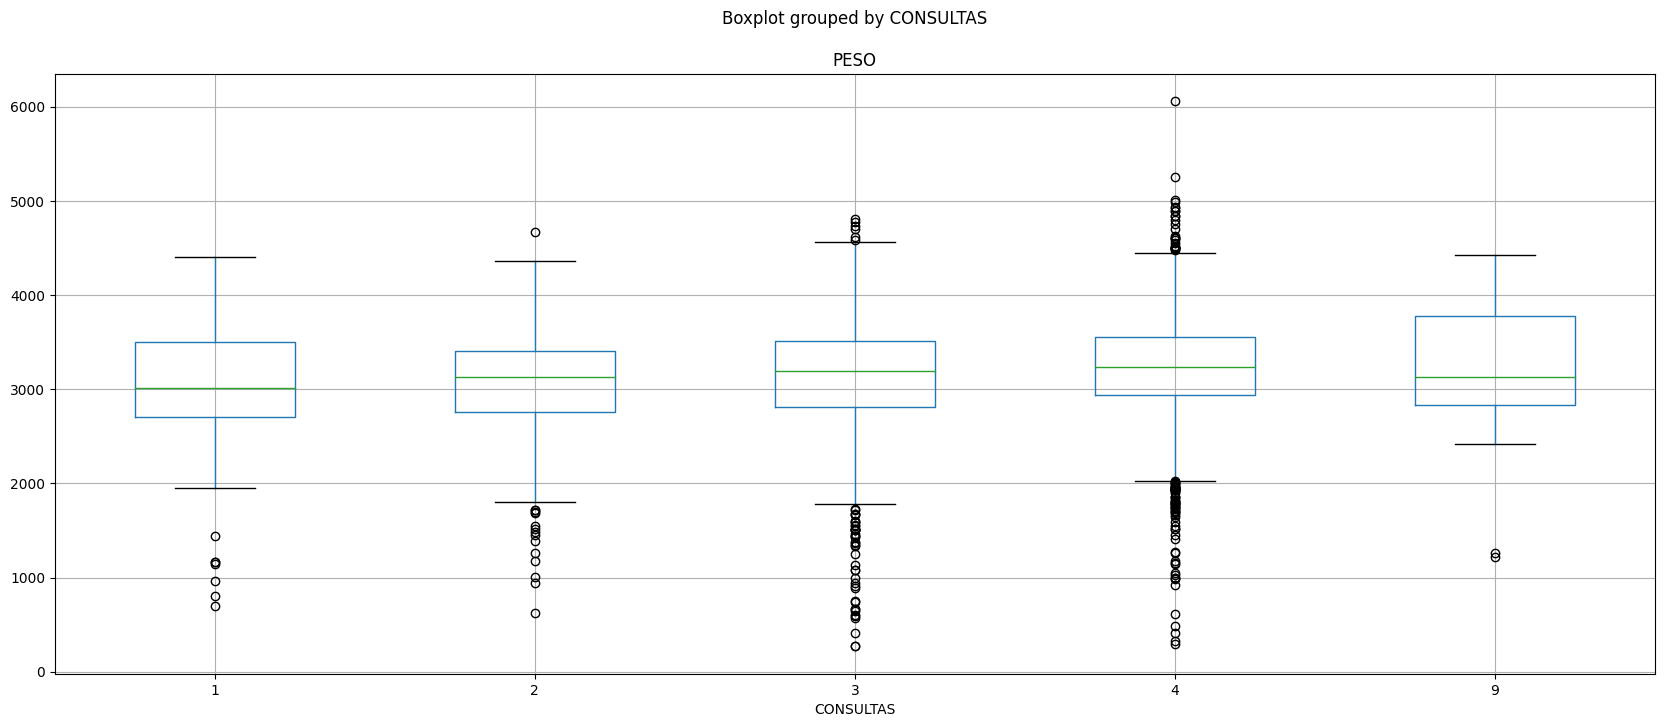

In [ ]:
#@title **Peso da Criança ao nascer pela quantidade de consultas pré-natal** { vertical-output: true, form-width: "60%" }

bp = sinasc.boxplot(column=['PESO'], by='CONSULTAS', figsize=(20,8))

## Gráfico de Dispersão

<div align='justify'>

O gráfico de dispersão mostra um ponto no gráfico representando a frequência dos valores de uma determinada variável

</div>

<Axes: xlabel='PESO', ylabel='IDADEMAE'>

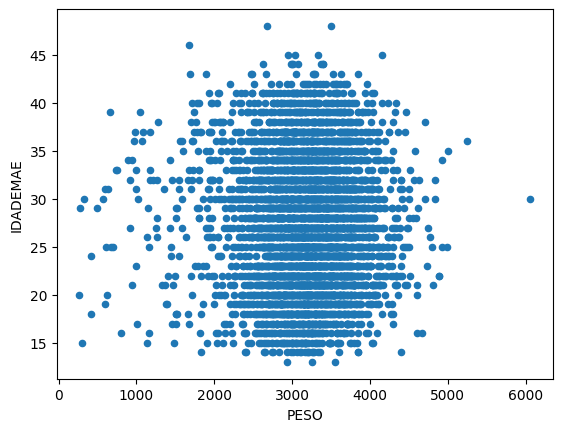

In [ ]:
sinasc.plot.scatter(x='PESO', y='IDADEMAE')

# Análises Bidimensionais

<div align='justify'>

Algumas vezes queremos analisar duas ou mais variáveis de forma conjunta. Normalmente o objetivo é explorar relações, similaridades ou associações, tanto entre variáveis diferentes (colunas), quanto entre grupos diferentes de indivíduos da base de dados. Queremos saber se a ocorrência do valor de uma variável influencia na ocorrência do valor de outra variável.

Podemos estudar a associação entre variáveis qualitativas, quantitativas e qualitativas com quantitativas.

</div>

## Associação entre Variáveis Qualitativas

<div align='justify'>

A associação entre variáveis qualitativas pode ser estudada por métodos gráficos, como tabelas de contingência, e por medidas de correlação.

</div>

### Tabelas de Contingência

<div align='justify'>

A tabela de contingência é uma tabela na qual aparecem as frequências absolutas das observações que pertencem simultaneamente a duas variáveis. Por exemplo, a quantidade meninas e meninos que nasceram com ou sem anomalia congênita.

</div>

In [ ]:
#@title **Anomalia congênita x sexo da criança** { vertical-output: true, form-width: "60%" }

conting_sa = pd.crosstab(sexo_anomal['SEXO'], sexo_anomal['IDANOMAL'], margins = True)
conting_sa

IDANOMAL,1.0,2.0,9.0,All
SEXO,,,,
1,24,2455,19,2498
2,25,2409,28,2462
All,49,4864,47,4960


In [ ]:
#@title **Tipo de gravidez x tipo de parto** { vertical-output: true, form-width: "60%" }
conting_gp = pd.crosstab(gravidez_parto['GRAVIDEZ'], gravidez_parto['PARTO'], margins = True)
conting_gp

PARTO,1.0,2.0,All
GRAVIDEZ,,,
1.0,2093,2775,4868
2.0,15,108,123
3.0,0,5,5
All,2108,2888,4996


In [ ]:
#@title **Tipo de gravidez x meses de gestação** { vertical-output: true, form-width: "60%" }
conting_gg = pd.crosstab(gravidez_gestacao['GRAVIDEZ'], gravidez_gestacao['GESTACAO'], margins = True)
conting_gg

GESTACAO,2.0,3.0,4.0,5.0,6.0,9.0,All
GRAVIDEZ,,,,,,,
1.0,13,46,443,4192,103,4,4801
2.0,4,5,64,50,0,0,123
3.0,1,0,4,0,0,0,5
All,18,51,511,4242,103,4,4929


### Chi Quadrado

<div align='justify'>

O chi quadrado é uma medida de afastamento global que serve para verificar se há algum tipo de associação entre as variáveis estudadas. Quanto mais próxima de 0, menor a associação e quanto maior, maior será a associação. O chi quadrado é uma medida calculada considerando a frequência observada e a frequência esperada.

Por exemplo, considere novamente a tabela de contingência de anomalia congênita por sexo da criança:

</div>

In [ ]:
#@title **Anomalia congênita x sexo da criança** { vertical-output: true, form-width: "60%" }

conting_sa

IDANOMAL,1.0,2.0,9.0,All
SEXO,,,,
1,24,2455,19,2498
2,25,2409,28,2462
All,49,4864,47,4960


In [ ]:
#@title **Tabela de contingência esperada**
from scipy.stats import chi2_contingency

c_sa, p, dof, expected = chi2_contingency(conting_sa)
pd.DataFrame(expected)

,0,1,2,3
0,24.677823,2449.651613,23.670565,2498.0
1,24.322177,2414.348387,23.329435,2462.0
2,49.000000,4864.000000,47.000000,4960.0


<div align='justify'>

O chi quadrado é calculado utilizado a frequência observada e esperada de cada grupo da tabela de contingência, pela seguinte fórmula:

</div>

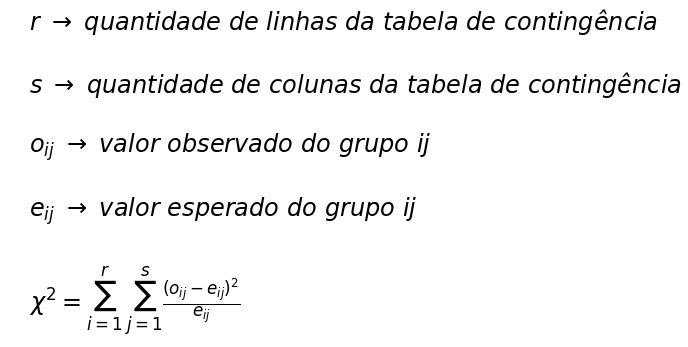

In [ ]:
#@title **Fórmula do chi quadrado**
plt.axes((0, 0, 0.1, 0.01), facecolor='w')
plt.box(False)
plt.xticks([])
plt.yticks([])
plt.title(
    r'$r\/\/\rightarrow\/\/quantidade\/\/de\/\/linhas\/\/da\/\/tabela\/\/de\/\/contingência$'+'\n\n'+
    r'$s\/\/\rightarrow\/\/quantidade\/\/de\/\/colunas\/\/da\/\/tabela\/\/de\/\/contingência$'+'\n\n'+
    r'$o_{ij}\/\/\rightarrow\/\/valor\/\/observado\/\/do\/\/grupo\/\/ij$'+'\n\n'+
    r'$e_{ij}\/\/\rightarrow\/\/valor\/\/esperado\/\/do\/\/grupo\/\/ij$'+'\n\n'+
    r'$\chi^2 = \sum_{i=1}^r\/ \sum_{j=1}^s\frac{(o_{ij} - e_{ij})^2}{e_{ij}}$'+'\t',
          fontdict={'fontsize':24, 'horizontalalignment':'left'})
plt.show()

**Chi quadrado utilizando python**

In [ ]:
#@title **Chi quadrado sexo x anomalia congênita** { vertical-output: true, form-width: "60%" }
# importar da biblioteca scipy.stats
from scipy.stats import chi2_contingency

c_sa, p, dof, expected = chi2_contingency(conting_sa)
c_sa

1.9176560119015313

In [ ]:
#@title **Chi quadrado tipo de gravidez x tipo de parto** { vertical-output: true, form-width: "60%" }
from scipy.stats import chi2_contingency

c_gp, p, dof, expected = chi2_contingency(conting_gp)
c_gp

50.31328407588558

In [ ]:
#@title **Chi quadrado tipo de gravidez x semanas de gestação** { vertical-output: true, form-width: "60%" }
from scipy.stats import chi2_contingency

c_gg, p, dof, expected = chi2_contingency(conting_gg)
c_gg

366.1389497980537

### Coeficiente de Contingência

<div align='justify'>

O coeficiente de contingência é outra medida para mostrar a correlação entre duas variáveis. Ela é calculada a partir do chi quadrado e da quantidade de observações. A interpretação e a mesma do chi quadrado: quanto maior, maior a associação, quanto menor, menor a associação.

É comum também calcular outro coeficiente, conhecido como T, para normalizar entre 0 e 1. Dessa forma a interpretação fica mais fácil.

</div>

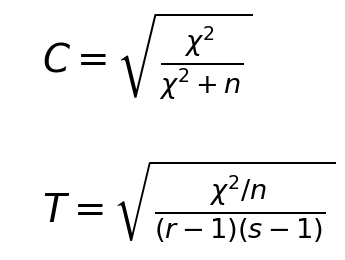

In [ ]:
#@title **Equação**
plt.axes((0, 0, 0.1, 0.01), facecolor='w')
plt.box(False)
plt.xticks([])
plt.yticks([])
plt.title(r'$C = \sqrt{\frac{\chi^2}{\chi^2 + n}}$'+'\n\n'+
          r'$T = \sqrt{\frac{\chi^2/n}{(r-1)(s-1)}}$',
          fontdict={'fontsize':28, 'horizontalalignment':'left'})
plt.show()

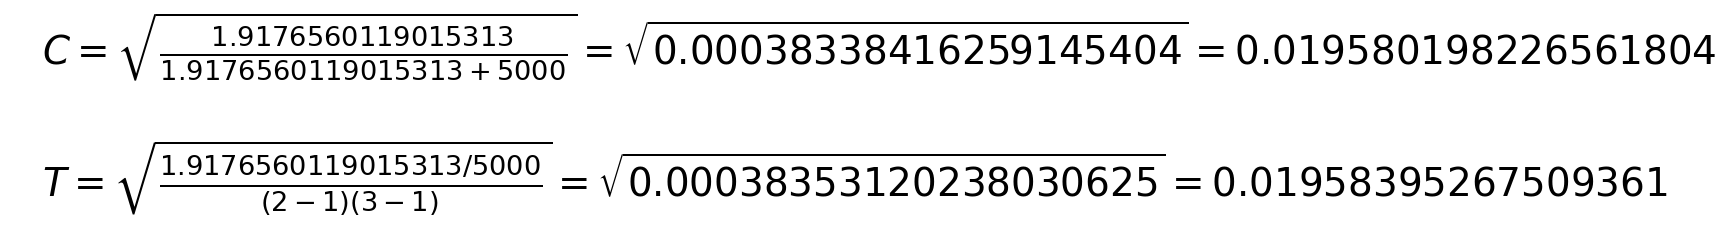

In [ ]:
#@title **Exemplo - sexo x anomalia congênita**
plt.axes((0, 0, 0.1, 0.01), facecolor='w')
plt.box(False)
plt.xticks([])
plt.yticks([])
plt.title(r'$C = \sqrt{\frac{'+str(c_sa)+r'}{'+str(c_sa)+r' + '+str(len(sexo_anomal))+'}}$'+
          r'$ = \sqrt{'+str(c_sa/(c_sa + len(sexo_anomal)))+r'}$'+
          r'$ = '+str((c_sa/(c_sa + len(sexo_anomal)))**(1/2))+r'$'+'\n\n'+
          r'$T = \sqrt{\frac{'+str(c_sa)+r'/'+str(len(sexo_anomal))+'}{('+str(conting_sa.shape[0]-1)+r'-1)('+str(conting_sa.shape[1]-1)+r'-1)}}$'+
          r'$ = \sqrt{'+str(c_sa/len(sexo_anomal))+r'}$'+
          r'$ = '+str((c_sa/(len(sexo_anomal)))**(1/2))+r'$',
          fontdict={'fontsize':28, 'horizontalalignment':'left'})
plt.show()

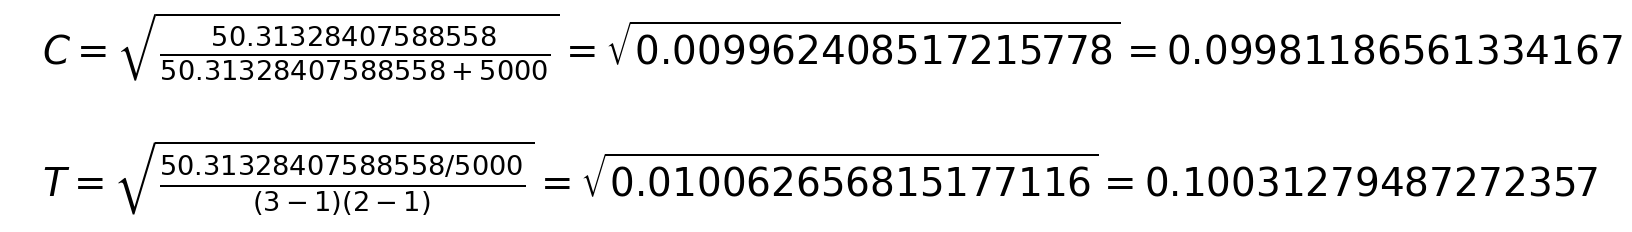

In [ ]:
#@title **Exemplo - tipo de gravidez x tipo de parto**
plt.axes((0, 0, 0.1, 0.01), facecolor='w')
plt.box(False)
plt.xticks([])
plt.yticks([])
plt.title(r'$C = \sqrt{\frac{'+str(c_gp)+r'}{'+str(c_gp)+r' + '+str(len(gravidez_parto))+'}}$'+
          r'$ = \sqrt{'+str(c_gp/(c_gp + len(gravidez_parto)))+r'}$'+
          r'$ = '+str((c_gp/(c_gp + len(gravidez_parto)))**(1/2))+r'$'+'\n\n'+
          r'$T = \sqrt{\frac{'+str(c_gp)+r'/'+str(len(gravidez_parto))+'}{('+str(conting_gp.shape[0]-1)+r'-1)('+str(conting_gp.shape[1]-1)+r'-1)}}$'+
          r'$ = \sqrt{'+str(c_gp/len(gravidez_parto))+r'}$'+
          r'$ = '+str((c_gp/(len(gravidez_parto)))**(1/2))+r'$',
          fontdict={'fontsize':28, 'horizontalalignment':'left'})
plt.show()

Text(0.5, 1.0, '$C = \\sqrt{\\frac{366.1389497980537}{366.1389497980537 + 5000}}$$ = \\sqrt{0.06823135837953521}$$ = 0.26121132896475835$\n\n$T = \\sqrt{\\frac{366.1389497980537/5000}{(3-1)(6-1)}}$$ = \\sqrt{0.07322778995961074}$$ = 0.2706063376190786$')

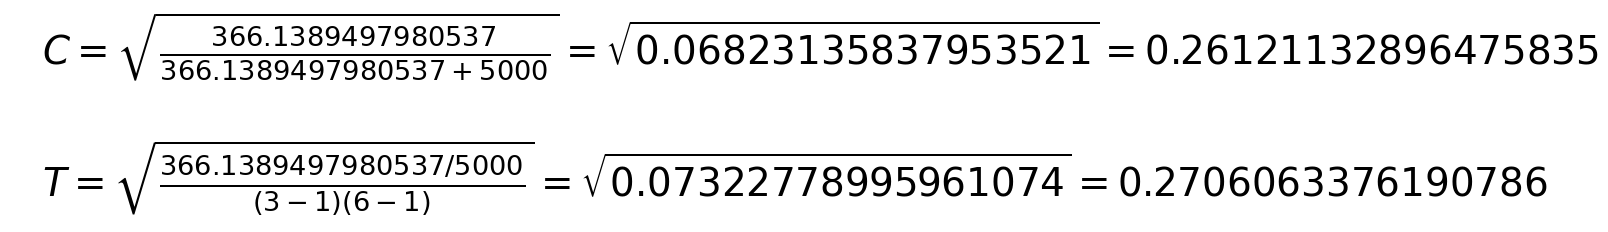

In [ ]:
#@title **Exemplo - tipo de gravidez x semanas de gestação**
plt.axes((0, 0, 0.1, 0.01), facecolor='w')
plt.box(False)
plt.xticks([])
plt.yticks([])
plt.title(r'$C = \sqrt{\frac{'+str(c_gg)+r'}{'+str(c_gg)+r' + '+str(len(gravidez_gestacao))+'}}$'+
          r'$ = \sqrt{'+str(c_gg/(c_gg + len(gravidez_gestacao)))+r'}$'+
          r'$ = '+str((c_gg/(c_gg + len(gravidez_gestacao)))**(1/2))+r'$'+'\n\n'+
          r'$T = \sqrt{\frac{'+str(c_gg)+r'/'+str(len(gravidez_gestacao))+'}{('+str(conting_gg.shape[0]-1)+r'-1)('+str(conting_gg.shape[1]-1)+r'-1)}}$'+
          r'$ = \sqrt{'+str(c_gg/len(gravidez_gestacao))+r'}$'+
          r'$ = '+str((c_gg/(len(gravidez_gestacao)))**(1/2))+r'$',
          fontdict={'fontsize':28, 'horizontalalignment':'left'})
plt.show()

## Associação entre Variáveis Quantitativas

<div align='justify'>

Os mesmos tipos de análises feitos para as variáveis qualitativas podem ser utilizados para as variáveis quantitativas, como a tabela de contingência e a associação entre as variáveis. A diferença pode ocorrer na quantidade de diferentes valores que estão sendo avaliados. Como se tratam de variáveis quantitativas, muitos valores diferentes podem ocorrer nas observações, então é comum agrupar os valores em intervalos de classes (como faixa etária).

Além dessas análises, as variáveis quantitativas possibilitam análises e gráficos mais elaborados, como gráfico de dispersão e coeficiente de correlação.

</div>

### Gráfico de dispersão

<div align='justify'>

Já vimos o gráfico de dispersão para mostrar a frequência de uma determinada variável. Este gráfico pode também ser utilizado em análises bidimensionais entre variáveis quantitativas para mostrar a relação entre duas variáveis. Cada eixo do gráfico será uma variável, e um ponto é colocado no cruzamento dos valores de x e y de uma observação.

Uma alternativa visual interessante para o gráfico de dispersão é aumentar o tamanho do ponto conforme a frequência dos agrupamentos.

</div>

In [ ]:
#@title **Tabela de idade da mãe e número de filhos vivos das mães casadas** { vertical-output: true, form-width: "60%" }
idade_filhosvivos

,QTDFILVIVO,IDADEMAE
0,3.0,34
1,0.0,20
2,0.0,21
5,0.0,24
8,0.0,18
...,...,...
4992,3.0,34
4993,0.0,20
4996,0.0,20
4997,2.0,25


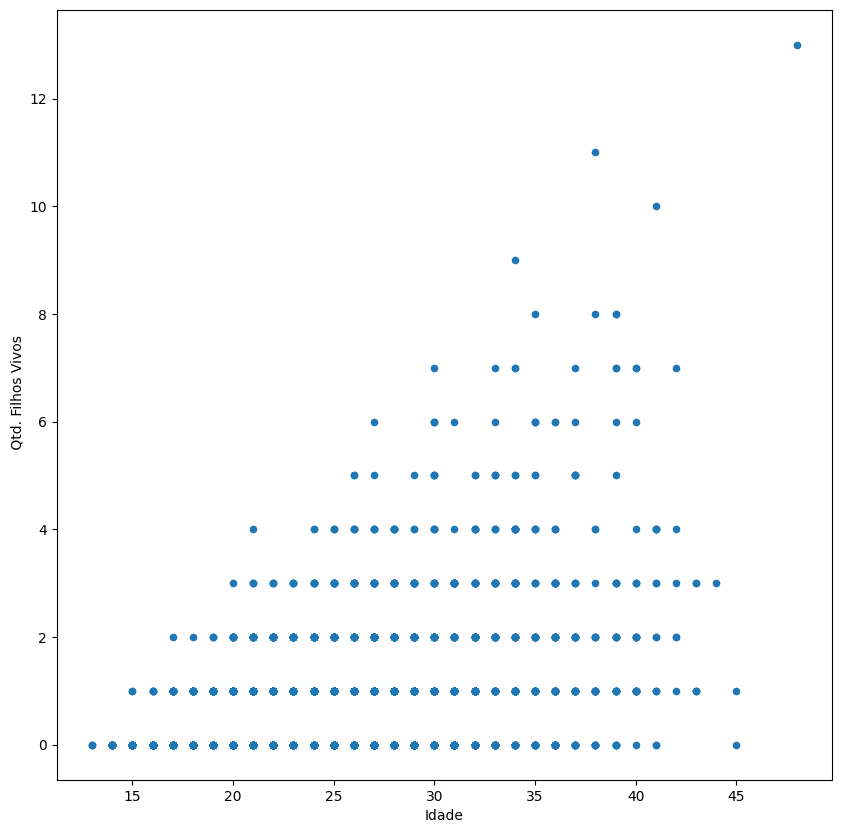

In [ ]:
#@title **Gráfico de dispersão idade x quantidade de filhos vivos** { vertical-output: true, form-width: "60%" }

disp = idade_filhosvivos.plot(x='IDADEMAE', y='QTDFILVIVO',  kind='scatter', figsize=(10,10), s=20)
r = disp.set(xlabel='Idade', ylabel=' Qtd. Filhos Vivos')


### Coeficiente de Correlação

<div align='justify'>

O coeficiente de correlação é uma medida do grau de associação entre duas variáveis quantitativas e de proximidade dos dados em uma reta.

O coeficiente de correlação utiliza a média e o desvio padrão populacional (σ), ou seja, o desvio padrão sem nenhum grau de liberdade (variância é dividida por N, e não N -1).

O coeficiente de correlação assumirá valores entre -1 e 1:
   

*   Quando mais próximo de 0, menor a correlação;
*   Quanto mais próximo de 1, maior a correlação positiva;
*   Quanto mais próximo de -1, maior a correlação negativa.


</div>

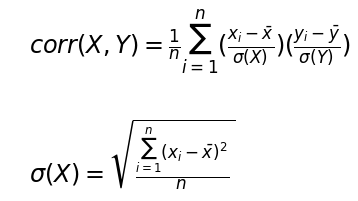

In [ ]:
#@title **Equação**

plt.axes((0, 0, 0.1, 0.01), facecolor='w')
plt.box(False)
plt.xticks([])
plt.yticks([])
plt.title(r'$corr(X,Y) = \frac{1}{n} \sum_{i=1}^n (\frac{x_i - \bar x}{\sigma(X)}) (\frac{y_i - \bar y}{\sigma(Y)})  $'+'\n\n'+
          r'$\sigma(X) = \sqrt{\frac{\sum_{i=1}^n (x_i - \bar x)^2}{n}}$',
          fontdict={'fontsize':24, 'horizontalalignment':'left'})
plt.show()

In [ ]:
#@title **Coeficiente de correlação com python e pandas - qtd. filhos vivos x idade da mãe** { vertical-output: true, form-width: "60%" }
idade_filhosvivos.corr()

,QTDFILVIVO,IDADEMAE
QTDFILVIVO,1.000000,0.461117
IDADEMAE,0.461117,1.000000


## Associação entre Variáveis Qualitativas e Quantitativas

Além de análises bidimensionais de associação entre variáveis do mesmo tipo, existem também as análises de associação entre variáveis quantitativas e qualitativas. É comum analisar o comportamento de uma variável quantitativa em diferentes categorias de uma variável qualitativa. Podem ser utilizadas medidas-resumo, histogramas e box-plot, por exemplo.


### Medidas-resumo

As medidas-resumo são as mesmas vistas no começo do curso. A diferença é que agora serão calculadas para agrupamentos de variáveis qualitativas, ao invés da amostra inteira. Por exemplo, agrupamos os dados por escolaridade, e calculamos as medidas resumo para cada uma das categorias.

In [ ]:
#@title **Medidas resumo para o peso da criança ao nascer pela quantidade de consultas pré-natal** { vertical-output: true, form-width: "60%" }
media = sinasc.groupby(['CONSULTAS'])[['PESO']].mean().rename(columns={"PESO": "MÉDIA"})
var = sinasc.groupby(['CONSULTAS'])[['PESO']].var().rename(columns={"PESO": "VAR"})
dp = sinasc.groupby(['CONSULTAS'])[['PESO']].std().rename(columns={"PESO": "DP"})
q1 = sinasc.groupby(['CONSULTAS'])[['PESO']].quantile(0.25).rename(columns={"PESO": "Q1"})
q2 = sinasc.groupby(['CONSULTAS'])[['PESO']].quantile(0.5).rename(columns={"PESO": "Q2"})
q3 = sinasc.groupby(['CONSULTAS'])[['PESO']].quantile(0.75).rename(columns={"PESO": "Q3"})
count = sinasc.groupby(['CONSULTAS'])[['PESO']].count().rename(columns={"PESO": "N"})

pd.concat([count, media, var, dp, q1, q2, q3], axis=1)



,N,MÉDIA,VAR,DP,Q1,Q2,Q3
CONSULTAS,,,,,,,
1,86,2977.325581,588099.728044,766.876605,2706.0,3008.0,3500.0
2,305,3050.514754,357112.849288,597.589198,2754.0,3130.0,3408.0
3,1004,3101.834661,429138.973633,655.086997,2809.0,3188.0,3512.5
4,3582,3226.667783,259765.085357,509.671547,2940.0,3240.0,3550.0
9,23,3176.565217,639573.166008,799.733184,2835.0,3130.0,3780.0


In [ ]:
#@title **Medidas-resumo para o número de filhos vivos pela escolaridade** { vertical-output: true, form-width: "60%" }
media = sinasc.groupby(['ESCMAE'])[['QTDFILVIVO']].mean().rename(columns={"QTDFILVIVO": "MÉDIA"})
var = sinasc.groupby(['ESCMAE'])[['QTDFILVIVO']].var().rename(columns={"QTDFILVIVO": "VAR"})
dp = sinasc.groupby(['ESCMAE'])[['QTDFILVIVO']].std().rename(columns={"QTDFILVIVO": "DP"})
q1 = sinasc.groupby(['ESCMAE'])[['QTDFILVIVO']].quantile(0.25).rename(columns={"QTDFILVIVO": "Q1"})
q2 = sinasc.groupby(['ESCMAE'])[['QTDFILVIVO']].quantile(0.5).rename(columns={"QTDFILVIVO": "Q2"})
q3 = sinasc.groupby(['ESCMAE'])[['QTDFILVIVO']].quantile(0.75).rename(columns={"QTDFILVIVO": "Q3"})
count = sinasc.groupby(['ESCMAE'])[['QTDFILVIVO']].count().rename(columns={"QTDFILVIVO": "N"})

pd.concat([count, media, var, dp, q1, q2, q3], axis=1)

<ipython-input-90-92a2454c3bbb>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media = sinasc.groupby(['ESCMAE'])[['QTDFILVIVO']].mean().rename(columns={"QTDFILVIVO": "MÉDIA"})
<ipython-input-90-92a2454c3bbb>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  var = sinasc.groupby(['ESCMAE'])[['QTDFILVIVO']].var().rename(columns={"QTDFILVIVO": "VAR"})
<ipython-input-90-92a2454c3bbb>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this w

,N,MÉDIA,VAR,DP,Q1,Q2,Q3
ESCMAE,,,,,,,
1.0,15,3.066667,11.638095,3.411465,0.5,1.0,6.5
2.0,59,3.050847,7.738749,2.781861,1.0,3.0,4.0
3.0,649,1.818182,2.815657,1.677992,1.0,2.0,3.0
4.0,3063,0.982370,1.287736,1.134785,0.0,1.0,2.0
5.0,1073,0.565704,0.548151,0.740372,0.0,0.0,1.0
9.0,28,1.214286,1.433862,1.197440,0.0,1.0,2.0


In [ ]:
#@title **Regressão Linear**

import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Gerando dados para regressão linear simples
np.random.seed(1)

x=np.random.randn(1000,1)
w=np.random.randn()
b=np.random.randn()

y=x*w+b +(np.random.randn(1000,1)*0.09)

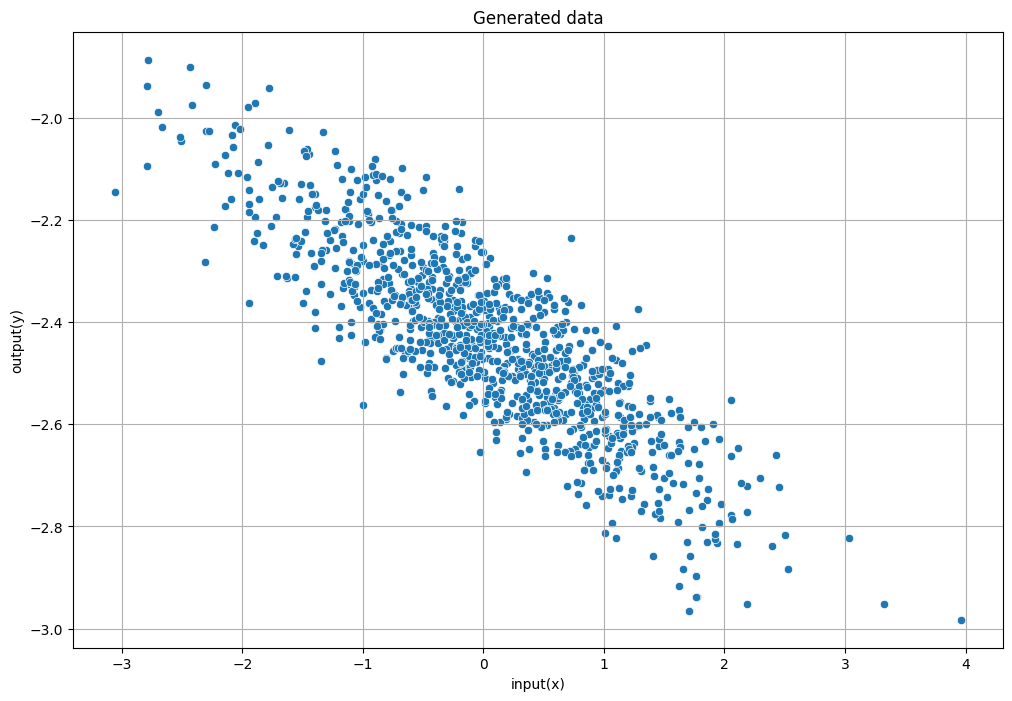

In [ ]:
# Visualizando os dados gerados
plt.figure(figsize=(12,8))
plt.title('Generated data')
plt.xlabel('input(x)')
plt.ylabel('output(y)')
sns.scatterplot(x=x[:,0],y=y[:,0])
plt.grid(True)
plt.show()

In [ ]:
#@title **Criando o modelo"
model = LinearRegression()
model.fit(x, y)

#Depois de ajustar seu modelo, você pode obter os resultados para verificar se ele funciona satisfatoriamente e interpretá-lo.
r_sq = model.score(x, y)
print(f"coefficient of determination: {r_sq}")

#Coeficientes a e b
print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")

#Reta ajustada
# y = -0,15*x - 2,42

coefficient of determination: 0.731194685171296
intercept: [-2.42966752]
slope: [[-0.15538586]]
